<a href="https://colab.research.google.com/github/Nvianafn/apan/blob/main/BLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

install dependensi

In [ ]:
!pip install transformers pillow torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

buat folder otomatis dan dataset

In [28]:
from transformers import BlipProcessor, BlipForQuestionAnswering
from PIL import Image
import torch
import json
import os

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)

# Path gambar
image_path = "/content/custom_dataset/berkebun.jpg"
image = Image.open(image_path).convert("RGB")

# Load semua pertanyaan
with open("/content/custom_dataset/questions.json", "r", encoding="utf-8") as f:
    all_questions = json.load(f)

# Tampilkan hasil
print(f"🖼️ Gambar: {os.path.basename(image_path)}\n")
for idx, question in enumerate(all_questions.values(), start=1):
    inputs = processor(image, question, return_tensors="pt").to(device)
    out = model.generate(**inputs)
    answer = processor.decode(out[0], skip_special_tokens=True)
    print(f"{idx}. ❓ {question}\n   ➡️ {answer}\n")


🖼️ Gambar: berkebun.jpg

1. ❓ Apa aktivitas utama di gambar ini?
   ➡️ unknown

2. ❓ Apakah gambar ini diambil di dalam atau luar ruangan?
   ➡️ i don ' t know

3. ❓ Apa warna dominan yang terlihat di gambar ini?
   ➡️ red

4. ❓ Berapa banyak orang yang ada di gambar ini?
   ➡️ nothing

5. ❓ Apakah ini suasana pagi, siang, atau malam?
   ➡️ 4

6. ❓ Apa emosi yang ditampilkan oleh orang di gambar?
   ➡️ i don ' t know

7. ❓ Apakah objek utama dalam gambar ini adalah hewan, manusia, atau benda?
   ➡️ arabic

8. ❓ Apakah ini termasuk dalam kategori alam atau kota?
   ➡️ 4

9. ❓ Apa yang sedang dilakukan orang dalam gambar ini?
   ➡️ standing

10. ❓ Apa hubungan antara objek-objek dalam gambar ini?
   ➡️ squatting



import model dan setup device

In [29]:
from transformers import BlipProcessor, BlipForQuestionAnswering
import torch
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to(device)


inferensi dan visualisasi

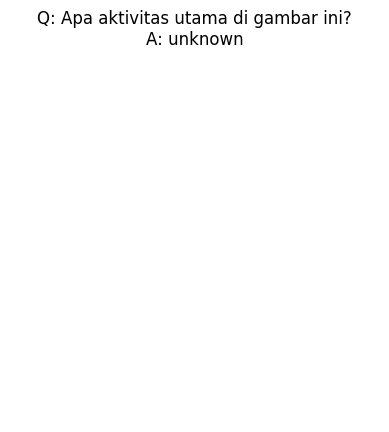

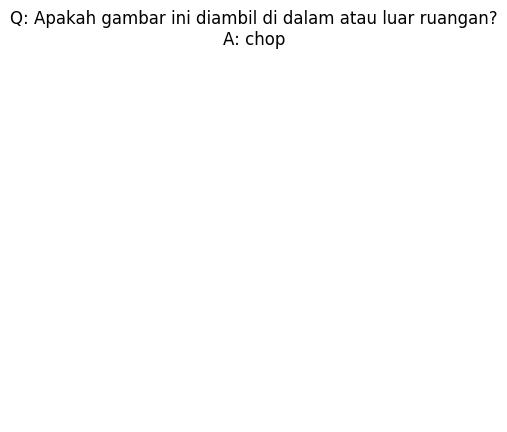

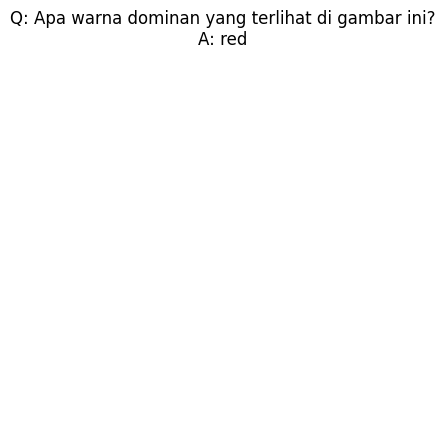

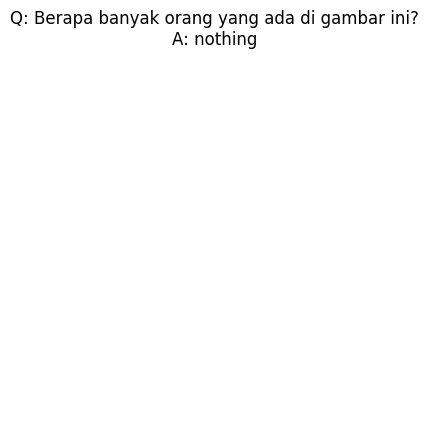

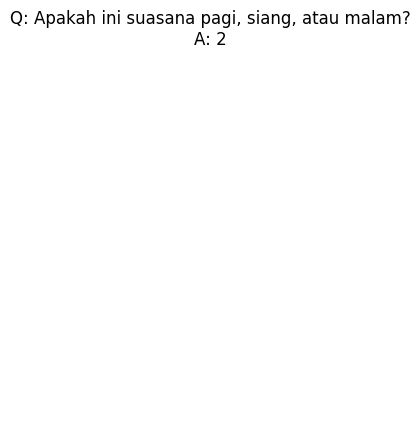

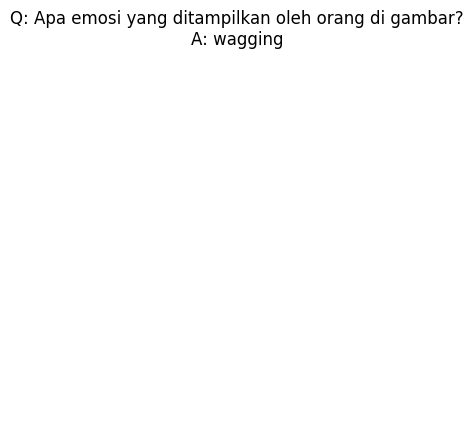

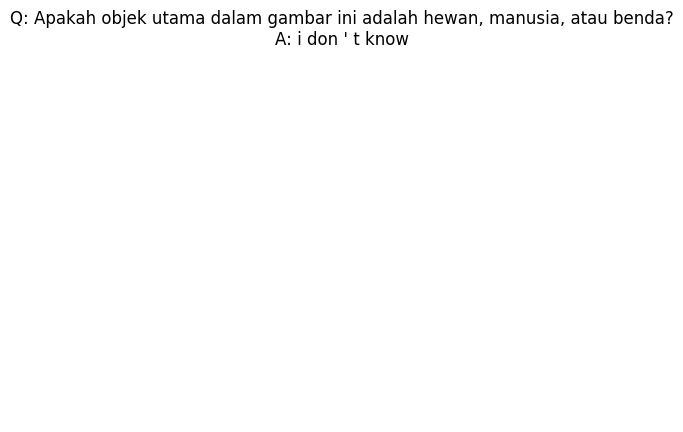

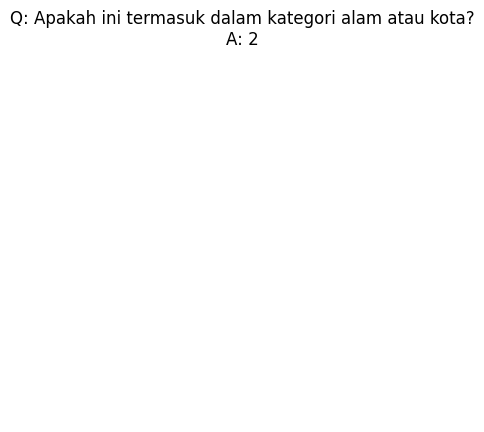

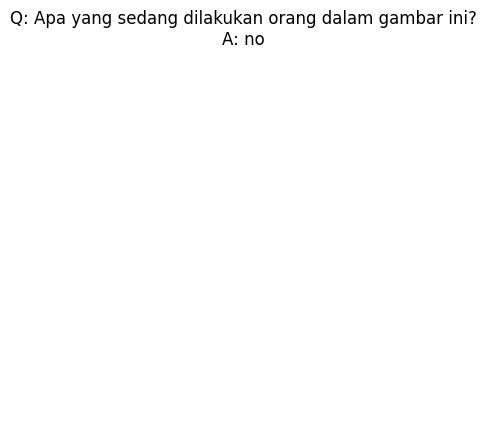

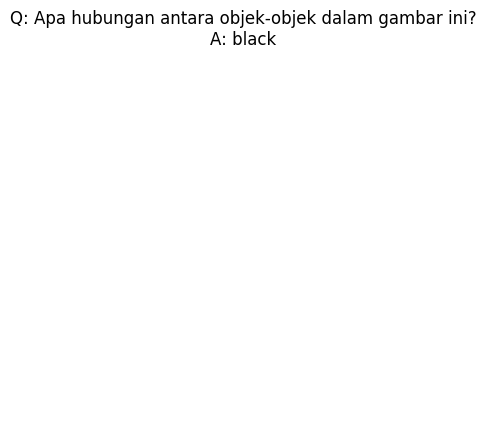

In [30]:
import os, json

dataset_dir = "/content/custom_dataset"

with open(os.path.join(dataset_dir, "questions.json"), "r", encoding="utf-8") as f:
    qa_pairs = json.load(f)

for image_name, question in qa_pairs.items():
    image_path = os.path.join(dataset_dir, image_name)
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, question, return_tensors="pt").to(device)
    out = model.generate(**inputs)
    answer = processor.decode(out[0], skip_special_tokens=True)

    plt.imshow(image)
    plt.title(f"Q: {question}\nA: {answer}")
    plt.axis("off")
    plt.show()
